In [1]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

Enter a city name:  Ashburn


Looking up coordinates for 'Ashburn'...
Found Ashburn in United States (Lat: 31.70601, Lon: -83.65322)
Fetching weather history...


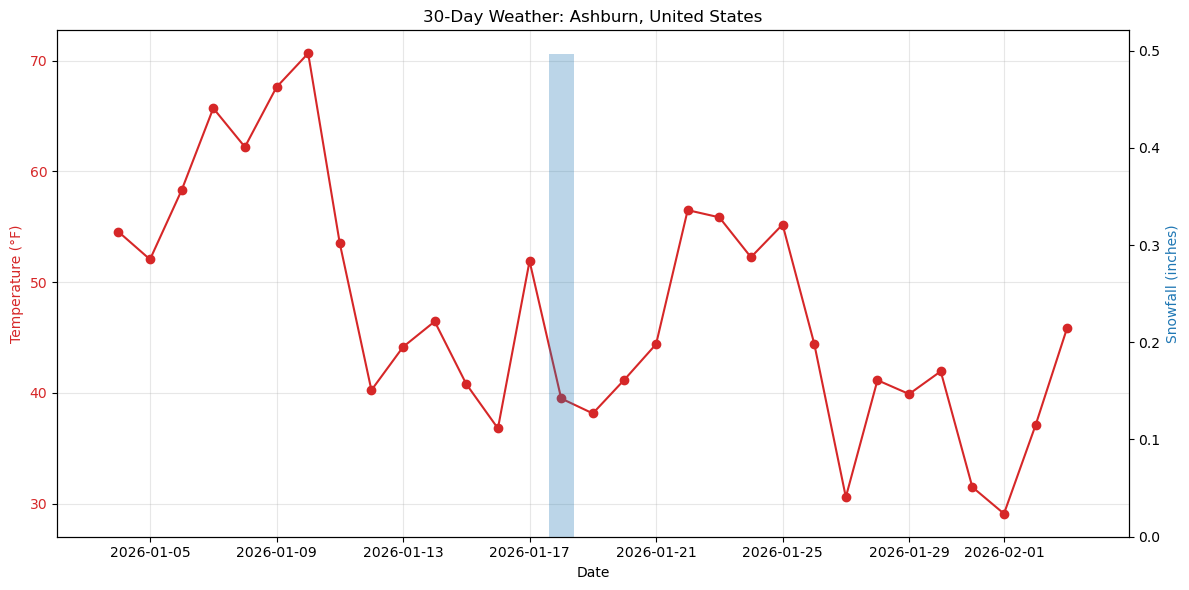

------------------------------
SUMMARY FOR ASHBURN
------------------------------
Average Temp:      47.4°F
Total Precip:      1.17 inches
Total Snowfall:    0.50 inches
------------------------------


In [2]:
# Step 1: Get user input
city_name = input("Enter a city name: ")

# Step 2: Geocoding
geocoding_url = "https://geocoding-api.open-meteo.com/v1/search"
geo_params = {
    "name": city_name,
    "count": 1,
    "language": "en",
    "format": "json"
}

print(f"Looking up coordinates for '{city_name}'...")
geo_response = requests.get(geocoding_url, params=geo_params)

if geo_response.status_code == 200 and "results" in geo_response.json():
    location_data = geo_response.json()["results"][0]
    lat = location_data["latitude"]
    lon = location_data["longitude"]
    country = location_data.get("country", "Unknown")
    
    print(f"Found {city_name} in {country} (Lat: {lat}, Lon: {lon})")

    weather_url = "https://archive-api.open-meteo.com/v1/archive"
    end_date = datetime.now().date()
    start_date = end_date - timedelta(days=30)

    weather_params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ["temperature_2m_max", "temperature_2m_min", "snowfall_sum", "precipitation_sum"],
        "timezone": "auto",
        "temperature_unit": "fahrenheit",
        "precipitation_unit": "inch"
    }

    print(f"Fetching weather history...")
    weather_response = requests.get(weather_url, params=weather_params)

    if weather_response.status_code == 200:
        data = weather_response.json()
        df = pd.DataFrame(data['daily'])
        df['time'] = pd.to_datetime(df['time'])

        df['avg_temp'] = (df['temperature_2m_max'] + df['temperature_2m_min']) / 2

        month_avg_temp = df['avg_temp'].mean()
        month_total_precip = df['precipitation_sum'].sum()
        month_total_snow = df['snowfall_sum'].sum()

        fig, ax1 = plt.subplots(figsize=(12, 6))

        # Temp Plot
        color_temp = 'tab:red'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Temperature (°F)', color=color_temp)
        ax1.plot(df['time'], df['avg_temp'], color=color_temp, marker='o', label='Avg Temp')
        ax1.tick_params(axis='y', labelcolor=color_temp)
        ax1.grid(True, alpha=0.3)

        ax2 = ax1.twinx()
        color_snow = 'tab:blue'
        ax2.set_ylabel('Snowfall (inches)', color=color_snow)
        ax2.bar(df['time'], df['snowfall_sum'], color=color_snow, alpha=0.3, label='Snowfall')

        plt.title(f'30-Day Weather: {city_name}, {country}')
        fig.tight_layout()
        plt.show()

        print("-" * 30)
        print(f"SUMMARY FOR {city_name.upper()}")
        print("-" * 30)
        print(f"Average Temp:      {month_avg_temp:.1f}°F")
        print(f"Total Precip:      {month_total_precip:.2f} inches")
        print(f"Total Snowfall:    {month_total_snow:.2f} inches")
        print("-" * 30)
            
    else:
        print(f"No results found for '{city_name}'. Please check the city name and try again.")
else:
    print(f"Error: Unable to fetch data. Status code: {geo_response.status_code}")